In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in ['EmployeeCount','Over18','StandardHours']:
    print(col)
    print(df[col].value_counts())
    print()

EmployeeCount
EmployeeCount
1    1470
Name: count, dtype: int64

Over18
Over18
Y    1470
Name: count, dtype: int64

StandardHours
StandardHours
80    1470
Name: count, dtype: int64



In [8]:
df.drop(
    ['EmployeeCount','Over18','StandardHours'],
    axis=1,
    inplace=True
)

In [9]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [10]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [11]:
pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [12]:
pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [13]:
df.groupby('Attrition')['MonthlyIncome'].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


In [14]:
df.groupby('Attrition')['Age'].mean()


,Age
Attrition,
No,37.561233
Yes,33.607595


In [15]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [16]:
df.groupby('Attrition')['YearsAtCompany'].mean()

,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


In [17]:
df.groupby('Attrition')['YearsSinceLastPromotion'].mean()

,YearsSinceLastPromotion
Attrition,
No,2.234388
Yes,1.945148


In [18]:
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [22]:
df['IncomePerYear'] = df['MonthlyIncome'] * 12

In [23]:
df['PromotionGap'] = (
    df['YearsSinceLastPromotion'] /
    (df['YearsAtCompany'] + 1)
)


In [24]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1,2,5,10,40],
    labels=[
        'New',
        'Early',
        'Mid',
        'Senior'
    ]
)

In [25]:
df[['IncomePerYear',
    'PromotionGap',
    'TenureGroup']].head()

,IncomePerYear,PromotionGap,TenureGroup
0,71916,0.000000,Mid
1,61560,0.090909,Mid
2,25080,0.000000,New
3,34908,0.333333,Mid
4,41616,0.666667,New


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Attrition',
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime',
    'TenureGroup'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   int64  
 2   BusinessTravel            1470 non-null   int64  
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   int64  
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   int64  
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   int64  
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   int64  
 14  JobSatis

In [28]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [29]:
print(X.shape)
print(y.shape)

(1470, 33)
(1470,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1176, 33)
Testing : (294, 33)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (1176, 33)
Testing Features  : (294, 33)
Training Labels : (1176,)
Testing Labels  : (294,)


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [34]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [35]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [36]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [37]:
lr_pred = log_reg.predict(X_test_scaled)

In [38]:
dt_pred = decision_tree.predict(X_test)
rf_pred = random_forest.predict(X_test)

In [39]:
print("Logistic Regression Predictions:", lr_pred[:10])
print("Decision Tree Predictions:", dt_pred[:10])
print("Random Forest Predictions:", rf_pred[:10])

Logistic Regression Predictions: [1 0 0 0 1 1 0 0 0 1]
Decision Tree Predictions: [0 0 0 0 0 0 0 0 0 0]
Random Forest Predictions: [1 0 0 0 0 0 0 0 0 0]


In [40]:
print("Logistic Regression Train Score:",
      log_reg.score(X_train_scaled, y_train))

print("Decision Tree Train Score:",
      decision_tree.score(X_train, y_train))

print("Random Forest Train Score:",
      random_forest.score(X_train, y_train))

Logistic Regression Train Score: 0.7636054421768708
Decision Tree Train Score: 0.8903061224489796
Random Forest Train Score: 1.0


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

========== Logistic Regression ==========

Accuracy : 0.7517006802721088
Precision: 0.3617021276595745
Recall   : 0.723404255319149
F1 Score : 0.48226950354609927
ROC-AUC  : 0.740244637781032

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       247
           1       0.36      0.72      0.48        47

    accuracy                           0.75       294
   macro avg       0.65      0.74      0.66       294
weighted avg       0.84      0.75      0.78       294



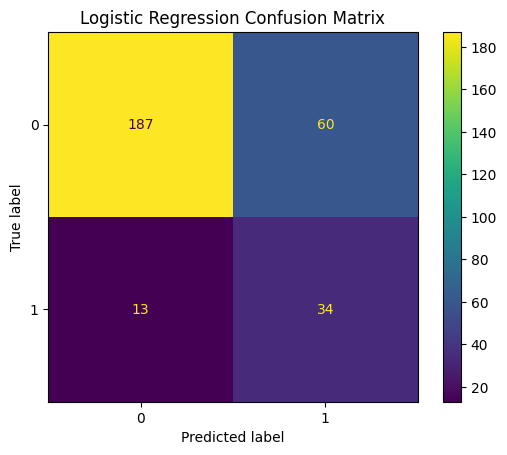

In [44]:
print("========== Logistic Regression ==========\n")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

========== Decision Tree ==========

Accuracy : 0.8435374149659864
Precision: 0.5294117647058824
Recall   : 0.19148936170212766
F1 Score : 0.28125
ROC-AUC  : 0.5795503488672581

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294



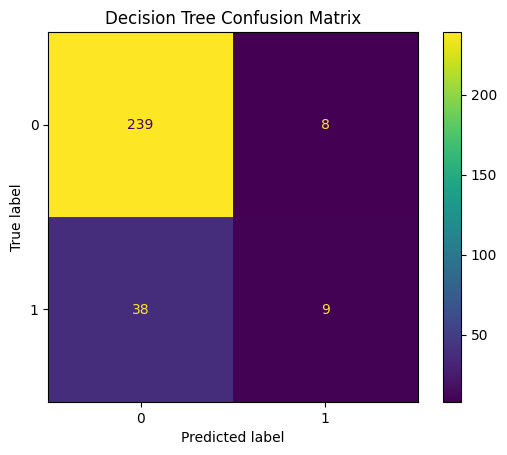

In [45]:
print("========== Decision Tree ==========\n")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_pred))

print("\nClassification Report\n")
print(classification_report(y_test, dt_pred))

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)
plt.title("Decision Tree Confusion Matrix")
plt.show()

========== Random Forest ==========

Accuracy : 0.8299319727891157
Precision: 0.3333333333333333
Recall   : 0.06382978723404255
F1 Score : 0.10714285714285714
ROC-AUC  : 0.519769144629167

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294



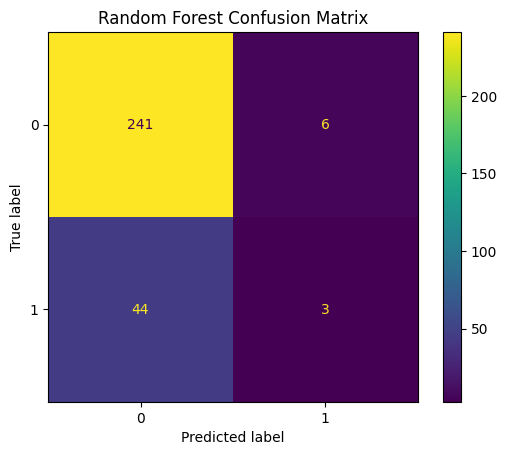

In [46]:
print("========== Random Forest ==========\n")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [47]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred)
    ]
})

results = results.sort_values(by='Accuracy', ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.843537,0.529412,0.191489,0.281250,0.579550
2,Random Forest,0.829932,0.333333,0.063830,0.107143,0.519769
0,Logistic Regression,0.751701,0.361702,0.723404,0.482270,0.740245


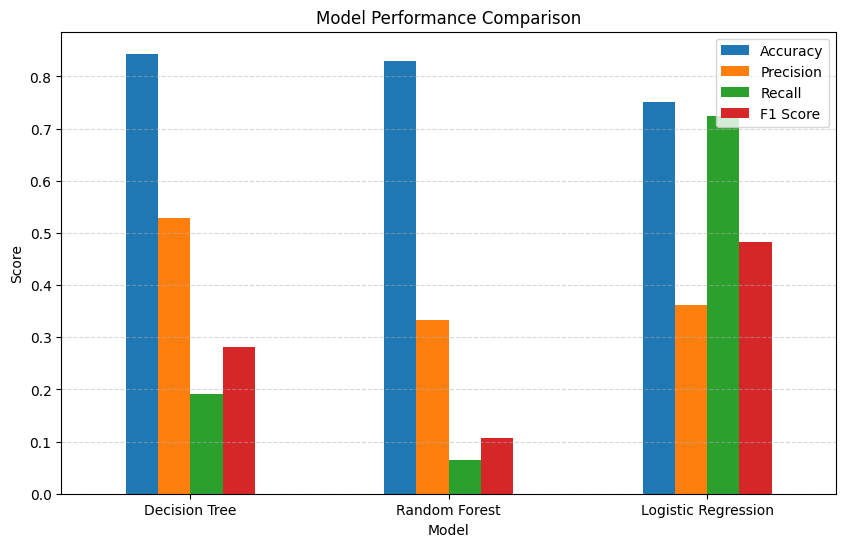

In [48]:
import matplotlib.pyplot as plt

results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [51]:
best_model = LogisticRegression

print("Best Model: ", best_model)

Best Model:  <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [53]:
import joblib

joblib.dump(best_model, "best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [55]:
# Scale the complete feature set
X_scaled = scaler.transform(X)

# Predict using Logistic Regression
predictions = log_reg.predict(X_scaled)

# Add predictions to the dataset
df["Predicted_Attrition"] = predictions

In [56]:

df["Predicted_Attrition"] = df["Predicted_Attrition"].map({
    0: "No",
    1: "Yes"
})

df["Attrition"] = df["Attrition"].map({
    0: "No",
    1: "Yes"
})

In [57]:
df.to_csv("HR_Attrition_LogisticRegression.csv", index=False)

print("CSV exported successfully!")

CSV exported successfully!
